In [1]:
import cv2 as cv
from skimage.io import imshow
from inspection.support.utils import cut

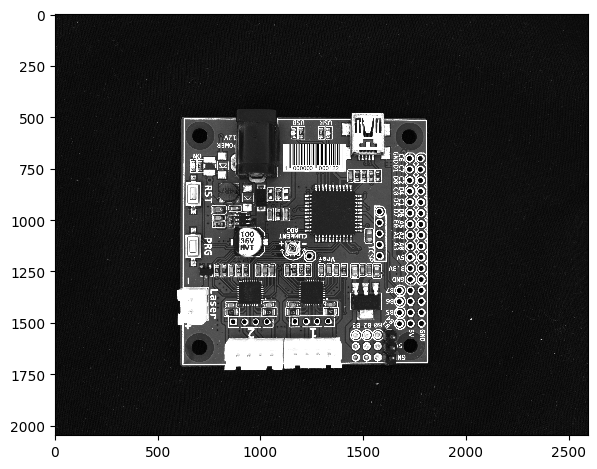

In [2]:
im = cv.cvtColor(
    cv.imread("inspection/support/barcode/drawcore.png"),
    cv.COLOR_BGR2GRAY,
)
imshow(im)

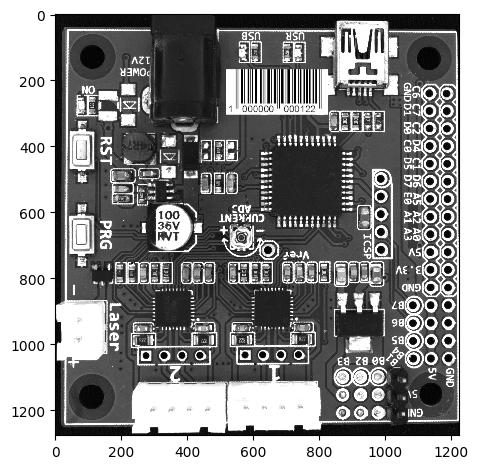

In [4]:
im1 = im

# Blur to vanish texture defects
im1 = cv.medianBlur(im1, 41)

# Arbitrary selected global threshold to separate background
val, im1 = cv.threshold(im1, 20, 255, cv.THRESH_BINARY)

analysis = cv.connectedComponentsWithStats(im1, cv.CV_32S)
(_, _, values, _) = analysis

# Select the biggest connected component (PCB desk)
mx, mxi = 0, 0
for i, value in enumerate(values):
    area = value[cv.CC_STAT_AREA]
    if area >= mx:
        mxi = i

value = values[mxi]
im2 = cut(im, value)

imshow(im2)

In [5]:
bardet = cv.barcode.BarcodeDetector()
bardet.detectAndDecode(im2)

('1000000000122', None, None)